In [1]:
# !pip install torch torchvision

# Importações

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import torch
import torchvision

# Leitura da Imagem

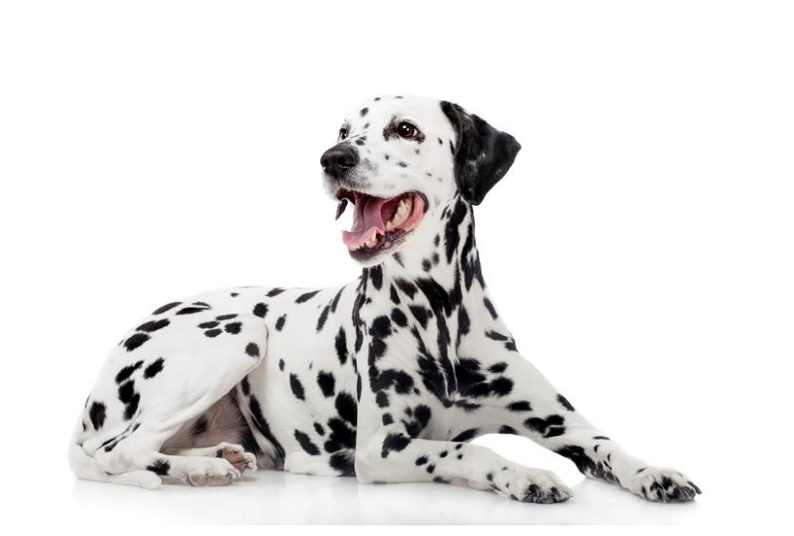

In [3]:
image = cv.imread(r'images\dog.jpeg')
image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.figure(figsize=(10,8))
plt.axis('off')
plt.imshow(image_rgb)


# Modelos pré treinados

In [4]:
# Definindo o peso a ser utilizado
weights = torchvision.models.VGG16_Weights.DEFAULT

# carrega os labels do dataset.
imagenet_labels = weights.meta['categories']

# carregar o modelo
vgg_16_model = torchvision.models.vgg16(weights)

# Criando o pipeline de transformações de pré-processamento dos dados
preprocess = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize(256),
    torchvision.transforms.CenterCrop(224),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229,0.224, 0.225]),
])

c:\Users\joelr\anaconda3\envs\computer_vision\Lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


In [5]:
# Vamos colocar o modelo em modo de avaliação
vgg_16_model.eval()

# pré processamento da imagem
image_tensor = preprocess(image_rgb)
input_batch = image_tensor.unsqueeze(0)

print(image_tensor.shape, input_batch.shape)

torch.Size([3, 224, 224]) torch.Size([1, 3, 224, 224])


In [6]:
# Escolhendo o dispositivo a ser utilizado GPU se disponivel
if torch.cuda.is_available():
    input_batch = input_batch.to('cuda')
    vgg_16_model.to('cuda')

# Rodando a inferência.
with torch.no_grad():
    output = vgg_16_model(input_batch)

# calculando a propabilidade das classes
probabilities = torch.nn.functional.softmax(output[0], dim=0)

classe predita para a imagem: dalmatian


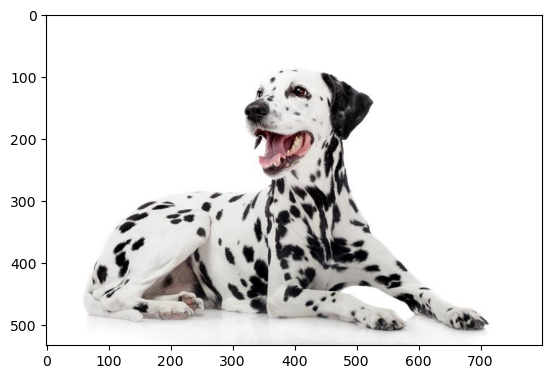

In [7]:
# Validando a classe prevista
print(f'classe predita para a imagem: {imagenet_labels[torch.argmax(probabilities)]}')
plt.imshow(image_rgb)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'EntleBucher'),
  Text(1, 0, 'boxer'),
  Text(2, 0, 'American Staffordshire terrier'),
  Text(3, 0, 'kuvasz'),
  Text(4, 0, 'bluetick'),
  Text(5, 0, 'muzzle'),
  Text(6, 0, 'German short-haired pointer'),
  Text(7, 0, 'English setter'),
  Text(8, 0, 'Great Dane'),
  Text(9, 0, 'dalmatian')])

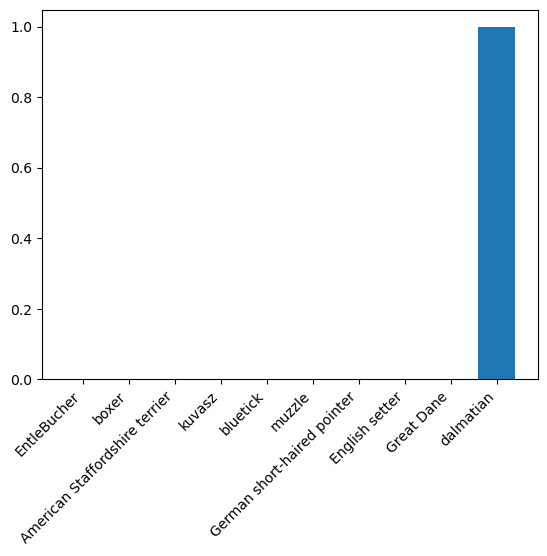

In [8]:
# Criar conjunto de labels e probabilidades e ordenar
set_labels_probs = list(zip(imagenet_labels, list(probabilities.cpu().numpy())))
set_labels_probs = sorted(set_labels_probs, key=lambda x:x[1])

# Pega as N classes mais provaveis
num = 10
most_probable_classes = set_labels_probs[-num:]

# Cria as listas para plot
labels, probs = zip(*most_probable_classes)

# Observando as probabilidades
plt.bar(labels, probs)
plt.xticks(rotation=45, ha='right') # rotate labels by 45 degrees and align tight